# F1-SIS: Safety Car Trigger Model

**Phase 2 — Model Training**  
**Task:** SC Trigger Model — XGBoost + SMOTE

---

## What this notebook does

Trains one model with one job:

> Given the state of the race at the end of lap `t`,  
> what is the probability that a Safety Car deploys **on lap `t+1`**?

**Why next lap, not this lap?**  
If SC is active NOW we already know it. The useful prediction is: given normal racing, will SC start next lap?

**Output:** A calibrated `P(SC starts next lap | current race state)` in `[0, 1]`

**Saved as:** `models/sc_trigger_xgboost.joblib` — loaded by the simulation engine at runtime

---

## Steps

1. Load data
2. Build SC label (forward-looking: next lap)
3. Engineer features
4. Split by season (train 2018-2022 / val 2023 / test 2024)
5. Handle class imbalance with SMOTE
6. Train XGBoost
7. Calibrate probabilities
8. Evaluate
9. Save model


---

## 1. Imports


In [1]:
import os
import warnings
import joblib
from pathlib import Path

warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# Machine learning
import xgboost as xgb
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from sklearn.isotonic import IsotonicRegression
from sklearn.metrics import (
    brier_score_loss,
    average_precision_score,
    roc_auc_score,
    precision_recall_curve,
)

# SMOTE for class imbalance
try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
    print('SMOTE: available')
except ImportError:
    SMOTE_AVAILABLE = False
    print('SMOTE not installed. Run: pip install imbalanced-learn')

print(f'XGBoost: {xgb.__version__}')
print('Imports done.')


SMOTE: available
XGBoost: 3.4.0
Imports done.


---

## 2. Configuration


In [2]:
# Data location
DATA_DIR = os.path.join('data_fastf1_v1', 'laps')

# Season split (matches project_spec.md)
TRAIN_SEASONS = [2018, 2019, 2020, 2021, 2022]
VAL_SEASONS   = [2023]
TEST_SEASONS  = [2024]

# Model output
MODEL_DIR = 'models/SC Estimation'
os.makedirs(MODEL_DIR, exist_ok=True)

# Reproducibility
RANDOM_SEED = 42

print('Config set.')
print(f'  Train seasons : {TRAIN_SEASONS}')
print(f'  Val season    : {VAL_SEASONS}')
print(f'  Test season   : {TEST_SEASONS}')
print(f'  Model output  : {MODEL_DIR}/')


Config set.
  Train seasons : [2018, 2019, 2020, 2021, 2022]
  Val season    : [2023]
  Test season   : [2024]
  Model output  : models/


---

## 3. Load Data

Loads all race CSVs from `data_fastf1_v1/laps/<year>/`. Each CSV is one race, with one row per driver per lap.


In [3]:
def load_all_races(data_dir=DATA_DIR):
    frames = []
    data_path = Path(data_dir)

    for season_dir in sorted(data_path.iterdir()):
        if not season_dir.is_dir():
            continue
        try:
            year = int(season_dir.name)
        except ValueError:
            continue

        for csv_file in sorted(season_dir.glob('*.csv')):
            try:
                df = pd.read_csv(csv_file, low_memory=False)
                df['Year']   = year
                df['source'] = csv_file.stem
                frames.append(df)
            except Exception as e:
                print(f'  WARNING: {csv_file.name}: {e}')

    if not frames:
        raise FileNotFoundError(f'No CSV files found in {data_dir}')

    df_all = pd.concat(frames, ignore_index=True)
    print(f'Loaded {len(frames)} races | {len(df_all):,} rows')
    return df_all


df_raw = load_all_races()
print(f'Columns: {list(df_raw.columns)}')
print(df_raw.head(3))


Loaded 172 races | 188,482 rows
Columns: ['Year', 'GrandPrix', 'Round', 'Country', 'Location', 'Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'DriverFullName', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'AirTemp', 'Humidity', 'Pressure', 'Rainfall', 'TrackTemp', 'WindDirection', 'WindSpeed', 'HasGreen', 'HasYellow', 'HasSafetyCar', 'HasRedFlag', 'HasVSC', 'HasVSCEnding', 'GapToLeader', 'IntervalToPositionAhead', 'GapToLeaderSeconds', 'IntervalToPositionAheadSeconds', 'TimeSeconds', 'LapTimeSeconds', 'PitInTimeSeconds', 'PitOutTimeSeconds', 'Sector1TimeSeconds', 'Sector2TimeSeconds', 'Sector3TimeSeconds', 'Sector1SessionTimeSeconds', 'Sector2SessionTi

---

## 4. Build the SC Label

The `TrackStatus` column contains digit-concatenated codes. Digit `4` means Safety Car is active.

**Label definition:** `sc_deployed = 1` if digit `4` is present in `TrackStatus`.

We aggregate to **race level** (one row per lap, not per driver), because the track status applies to the whole field.

SC laps are **excluded from the training features** (project spec: *'Remove SC / VSC laps — lap times are not representative of true pace'*). But we still need them to build the label correctly.


In [4]:
def has_digit(status_series, digit):
    # Returns True if the given digit appears in the TrackStatus code
    return status_series.astype(str).str.contains(str(digit))


def build_race_level(df):
    # Aggregate driver-lap data to one row per race lap
    df = df.copy()
    df['LapNumber']   = pd.to_numeric(df['LapNumber'], errors='coerce')
    df['TrackStatus'] = pd.to_numeric(df['TrackStatus'], errors='coerce').fillna(1).astype(int)

    # SC active = any driver on a lap has digit 4 in TrackStatus
    df['sc_active'] = has_digit(df['TrackStatus'], '4')

    # Group by race + lap number
    race_cols = ['Year', 'source', 'LapNumber']
    agg = df.groupby(race_cols).agg(
        sc_active     = ('sc_active',    'any'),
        n_cars        = ('Driver',       'nunique'),
        lap_time_med  = ('LapTimeSeconds','median'),
        lap_time_std  = ('LapTimeSeconds','std'),
        tyre_age_med  = ('TyreLife',      'median'),
        air_temp      = ('AirTemp',        'median'),
        track_temp    = ('TrackTemp',      'median'),
        humidity      = ('Humidity',       'median'),
        rainfall      = ('Rainfall',       'any'),
        total_pits    = ('PitInTime',      lambda x: x.notna().sum()),
    ).reset_index()

    # Total laps in the race
    max_lap = df.groupby(['Year', 'source'])['LapNumber'].max().reset_index()
    max_lap.columns = ['Year', 'source', 'total_laps']
    agg = agg.merge(max_lap, on=['Year', 'source'], how='left')

    agg['race_progress'] = agg['LapNumber'] / agg['total_laps']

    # Retirements: cars that disappeared
    agg = agg.sort_values(['Year', 'source', 'LapNumber'])
    agg['peak_cars']    = agg.groupby(['Year', 'source'])['n_cars'].transform('cummax')
    agg['retirements']  = (agg['peak_cars'] - agg['n_cars']).clip(lower=0)

    return agg


print('Building race-level timeline...')
df_laps = build_race_level(df_raw)
print(f'Race-level rows: {len(df_laps):,}')
print(f'Races: {df_laps[["Year","source"]].drop_duplicates().shape[0]}')
print(f'SC laps: {df_laps["sc_active"].sum()} ({df_laps["sc_active"].mean():.1%} of all laps)')


Building race-level timeline...
Race-level rows: 10,317
Races: 172
SC laps: 672 (6.5% of all laps)


---

## 5. Build `sc_deployed` Column

`sc_deployed = 1` on the lap the SC **first activates**. Subsequent SC laps are part of the same event — not new deployments.

Why this distinction matters: we want the model to predict **new SC events**, not just 'is SC already running?'.


In [5]:
def add_sc_label(df):
    df = df.sort_values(['Year', 'source', 'LapNumber']).copy()

    # Was SC active on the previous lap?
    df['sc_prev']    = df.groupby(['Year','source'])['sc_active'].shift(1, fill_value=False)

    # SC STARTS = SC newly active (was off, now on)
    df['sc_started'] = (~df['sc_prev']) & df['sc_active']
    df['sc_started'] = df['sc_started'].astype(int)

    # FORWARD-LOOKING LABEL: will SC start on the NEXT lap?
    # shift(-1) looks ahead one lap; fillna(0) = no SC after race ends
    df['sc_next'] = (
        df.groupby(['Year','source'])['sc_started']
        .shift(-1)
        .fillna(0)
        .astype(int)
    )

    df.drop(columns=['sc_prev'], inplace=True)
    return df


df_laps = add_sc_label(df_laps)

# Stats on NON-SC laps (where we actually make predictions)
normal_laps  = df_laps[df_laps['sc_active'] == False]
total_events = normal_laps['sc_next'].sum()
total_laps   = len(normal_laps)
print(f'Non-SC race laps     : {total_laps:,}')
print(f'SC starts next lap   : {total_events}')
print(f'Event rate           : {total_events/total_laps:.2%} of laps')
print(f'Class imbalance      : ~1:{total_laps//max(total_events,1)}')
print()
print(df_laps[['Year','source','LapNumber','sc_active','sc_started','sc_next']].head(15))


Non-SC race laps     : 9,645
SC starts next lap   : 92
Event rate           : 0.95% of laps
Class imbalance      : ~1:104

    Year                source  LapNumber  sc_active  sc_started  sc_next
0   2018  Abu_Dhabi_Grand_Prix        1.0       True           1        0
1   2018  Abu_Dhabi_Grand_Prix        2.0       True           0        0
2   2018  Abu_Dhabi_Grand_Prix        3.0       True           0        0
3   2018  Abu_Dhabi_Grand_Prix        4.0       True           0        0
4   2018  Abu_Dhabi_Grand_Prix        5.0      False           0        0
5   2018  Abu_Dhabi_Grand_Prix        6.0      False           0        0
6   2018  Abu_Dhabi_Grand_Prix        7.0      False           0        0
7   2018  Abu_Dhabi_Grand_Prix        8.0      False           0        0
8   2018  Abu_Dhabi_Grand_Prix        9.0      False           0        0
9   2018  Abu_Dhabi_Grand_Prix       10.0      False           0        0
10  2018  Abu_Dhabi_Grand_Prix       11.0      False           

---

## 6. Feature Engineering

All features must be available at the **end of lap `t`** — no future data.

| Feature | What it captures |
|---------|------------------|
| `lap_number` | Absolute lap in race |
| `race_progress` | lap / total_laps |
| `tyre_age_med` | Field-wide average tyre age |
| `lap_time_std` | Variance in pace — spread signals incidents |
| `retirements` | Cumulative cars retired |
| `total_pits` | Pit activity this lap |
| `track_temp` | Track temperature |
| `rainfall` | Rain flag |
| `sc_count_prev` | How many SCs already happened in this race |
| `laps_since_last_sc` | Time since previous SC (999 = none yet) |

> **No future data.** All rolling/cumulative features use `.shift(1)` to ensure they only reflect what was known *before* the current lap.


In [6]:
def build_features(df):
    df = df.sort_values(['Year', 'source', 'LapNumber']).copy()

    # Cumulative SC count BEFORE this lap (shift by 1 so no leakage)
    df['sc_count_prev'] = (
        df.groupby(['Year','source'])['sc_started'].cumsum().shift(1, fill_value=0)
    )

    # Laps since last SC deployment
    def laps_since_sc(group):
        result = []
        last_sc = None
        for i, (_, row) in enumerate(group.iterrows()):
            if i > 0 and group.iloc[i-1]['sc_started'] == 1:
                last_sc = group.iloc[i-1]['LapNumber']
            if last_sc is not None:
                result.append(row['LapNumber'] - last_sc)
            else:
                result.append(999)  # 999 = no SC yet in this race
        return result

    lss_col = []
    for _, grp in df.groupby(['Year','source']):
        lss_col.extend(laps_since_sc(grp))
    df['laps_since_last_sc'] = lss_col

    # Cumulative retirements (already computed)
    # Pit activity rolling sum (last 3 laps)
    df['pits_last3'] = (
        df.groupby(['Year','source'])['total_pits']
        .transform(lambda x: x.shift(1).rolling(3, min_periods=1).sum())
        .fillna(0)
    )

    # Lap time standard deviation (nan-safe)
    df['lap_time_std'] = df['lap_time_std'].fillna(0)

    # Rainfall as integer
    df['rainfall_flag'] = df['rainfall'].astype(int)

    # Fill remaining NaNs with column median
    for col in ['tyre_age_med', 'air_temp', 'track_temp', 'humidity']:
        if col in df.columns:
            df[col] = df[col].fillna(df[col].median())

    return df


df_laps = build_features(df_laps)
print('Features built.')
print(df_laps[['Year','source','LapNumber','sc_started','sc_count_prev','laps_since_last_sc']].head(10))


Features built.
   Year                source  LapNumber  sc_started  sc_count_prev  \
0  2018  Abu_Dhabi_Grand_Prix        1.0           1              0   
1  2018  Abu_Dhabi_Grand_Prix        2.0           0              1   
2  2018  Abu_Dhabi_Grand_Prix        3.0           0              1   
3  2018  Abu_Dhabi_Grand_Prix        4.0           0              1   
4  2018  Abu_Dhabi_Grand_Prix        5.0           0              1   
5  2018  Abu_Dhabi_Grand_Prix        6.0           0              1   
6  2018  Abu_Dhabi_Grand_Prix        7.0           0              1   
7  2018  Abu_Dhabi_Grand_Prix        8.0           0              1   
8  2018  Abu_Dhabi_Grand_Prix        9.0           0              1   
9  2018  Abu_Dhabi_Grand_Prix       10.0           0              1   

   laps_since_last_sc  
0               999.0  
1                 1.0  
2                 2.0  
3                 3.0  
4                 4.0  
5                 5.0  
6                 6.0  
7         

---

## 7. Chronological Train / Val / Test Split

Split by **season**, never by lap. Laps within a race are correlated — random splitting would leak future information.

| Split | Seasons | Notes |
|-------|---------|-------|
| Train | 2018--2022 | Model fitting + SMOTE |
| Val | 2023 | Calibration + hyperparameter tuning |
| Test | 2024 | Final evaluation (touch only once) |

We also **exclude SC-active laps from the feature set** during training (lap times on SC laps are unrepresentative — see project spec Section 7).


In [7]:
FEATURE_COLS = [
    'LapNumber',
    'race_progress',
    'tyre_age_med',
    'lap_time_std',
    'retirements',
    'total_pits',
    'pits_last3',
    'track_temp',
    'air_temp',
    'humidity',
    'rainfall_flag',
    'sc_count_prev',
    'laps_since_last_sc',
    'n_cars',
]

TARGET_COL = 'sc_next'  # Forward-looking: will SC start NEXT lap?

# Only keep laps where SC is NOT currently active.
# - These are the only laps where prediction makes sense (if SC is active, we already know)
# - sc_next=1 on laps immediately before an SC deployment
df_pred = df_laps[df_laps['sc_active'] == False].copy()

train_df = df_pred[df_pred['Year'].isin(TRAIN_SEASONS)]
val_df   = df_pred[df_pred['Year'].isin(VAL_SEASONS)]
test_df  = df_pred[df_pred['Year'].isin(TEST_SEASONS)]

avail_features = [c for c in FEATURE_COLS if c in df_pred.columns]

X_train = train_df[avail_features].fillna(0)
y_train = train_df[TARGET_COL]

X_val   = val_df[avail_features].fillna(0)
y_val   = val_df[TARGET_COL]

X_test  = test_df[avail_features].fillna(0)
y_test  = test_df[TARGET_COL]

print(f'Features used : {avail_features}')
print(f'Train : {len(X_train):>6,} laps | {y_train.sum():>4} SC-next events ({y_train.mean():.2%})')
print(f'Val   : {len(X_val):>6,} laps | {y_val.sum():>4} SC-next events ({y_val.mean():.2%})')
print(f'Test  : {len(X_test):>6,} laps | {y_test.sum():>4} SC-next events ({y_test.mean():.2%})')
assert y_train.sum() > 0, 'ERROR: No SC events in training set!'
assert y_val.sum()   > 0, 'ERROR: No SC events in validation set!'


Features used : ['LapNumber', 'race_progress', 'tyre_age_med', 'lap_time_std', 'retirements', 'total_pits', 'pits_last3', 'track_temp', 'air_temp', 'humidity', 'rainfall_flag', 'sc_count_prev', 'laps_since_last_sc', 'n_cars']
Train :  5,657 laps |   58 SC-next events (1.03%)
Val   :  1,258 laps |   13 SC-next events (1.03%)
Test  :  1,379 laps |    9 SC-next events (0.65%)


---

## 8. Handle Class Imbalance with SMOTE

SC events are rare (~2--5% of laps). Without handling this, the model would simply predict 'no SC' on every lap and be 95% accurate — which is useless for a strategy system.

**SMOTE** (Synthetic Minority Over-sampling Technique) creates synthetic SC examples in the training set. It is **only applied to training data** — never validation or test.


In [8]:
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=RANDOM_SEED)
    X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
    print(f'Before SMOTE: {y_train.sum()} SC / {len(y_train)} total = {y_train.mean():.2%}')
    print(f'After SMOTE : {y_train_sm.sum()} SC / {len(y_train_sm)} total = {y_train_sm.mean():.2%}')
else:
    # Fallback: use XGBoost scale_pos_weight instead
    X_train_sm, y_train_sm = X_train, y_train
    print('SMOTE not available. Using scale_pos_weight in XGBoost instead.')


Before SMOTE: 58 SC / 5657 total = 1.03%
After SMOTE : 5599 SC / 11198 total = 50.00%


---

## 9. Train XGBoost

**Why XGBoost?** From project_spec.md:

> *"XGBoost — SC trigger, pit decision, rain, overtake models"*

XGBoost handles tabular data well, trains fast, and supports SHAP explanations natively (needed for the Explainability Engine in Phase 6).


In [9]:
# Calculate scale_pos_weight as fallback if SMOTE not available
counts     = y_train.value_counts()
pos_weight = float(counts.get(0, 1) / max(counts.get(1, 1), 1))

model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 5,
    learning_rate     = 0.05,
    scale_pos_weight  = pos_weight if not SMOTE_AVAILABLE else 1.0,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    eval_metric       = 'logloss',
    random_state      = RANDOM_SEED,
    tree_method       = 'hist',
    verbosity         = 0,
)

print('Training XGBoost...')
model.fit(
    X_train_sm, y_train_sm,
    eval_set=[(X_val, y_val)],
    verbose=False,
)
print('Training complete.')


Training XGBoost...
Training complete.


---

## 10. Probability Calibration

The raw XGBoost probabilities may be over- or under-confident. The Monte Carlo simulation depends on probabilities being accurate — a '20% SC probability' should mean SC happens in 20% of similar situations.

We fit **isotonic regression** on the validation set to map raw scores to calibrated probabilities.


In [10]:
# Raw probabilities on validation set
raw_val_probs = model.predict_proba(X_val)[:, 1]

# Fit calibrator on validation set ONLY
calibrator = IsotonicRegression(out_of_bounds='clip')
calibrator.fit(raw_val_probs, y_val)

cal_val_probs = calibrator.predict(raw_val_probs)

print(f'Pos rate in val         : {y_val.mean():.4f}')
print(f'Raw mean predicted prob  : {raw_val_probs.mean():.4f}')
print(f'Calibrated mean prob     : {cal_val_probs.mean():.4f}')


Pos rate in val         : 0.0103
Raw mean predicted prob  : 0.0690
Calibrated mean prob     : 0.0103


---

## 11. Evaluation

**Why not accuracy?** The model is ~95% 'accurate' if it always predicts no-SC. Accuracy is misleading for rare events.

We use:
- **Brier Score** — measures probability accuracy (lower = better)
- **PR-AUC** — precision-recall under class imbalance (higher = better)
- **Calibration plot** — are the predicted probabilities realistic?


In [11]:
def evaluate(y_true, y_prob, label):
    brier  = brier_score_loss(y_true, y_prob)
    pr_auc = average_precision_score(y_true, y_prob)
    roc    = roc_auc_score(y_true, y_prob)
    print(f'[{label}]')
    print(f'  Brier Score : {brier:.4f}  (lower = better, baseline = {y_true.mean()*(1-y_true.mean()):.4f})')
    print(f'  PR-AUC      : {pr_auc:.4f}  (higher = better, baseline = {y_true.mean():.4f})')
    print(f'  ROC-AUC     : {roc:.4f}')
    print()
    return {'label': label, 'brier': brier, 'pr_auc': pr_auc, 'roc_auc': roc}


print('=== Validation Set Evaluation ===')
results_raw = evaluate(y_val.values, raw_val_probs, 'XGBoost (raw, uncalibrated)')
results_cal = evaluate(y_val.values, cal_val_probs, 'XGBoost (calibrated)')


=== Validation Set Evaluation ===
[XGBoost (raw, uncalibrated)]
  Brier Score : 0.0372  (lower = better, baseline = 0.0102)
  PR-AUC      : 0.0090  (higher = better, baseline = 0.0103)
  ROC-AUC     : 0.4159

[XGBoost (calibrated)]
  Brier Score : 0.0102  (lower = better, baseline = 0.0102)
  PR-AUC      : 0.0129  (higher = better, baseline = 0.0103)
  ROC-AUC     : 0.5647



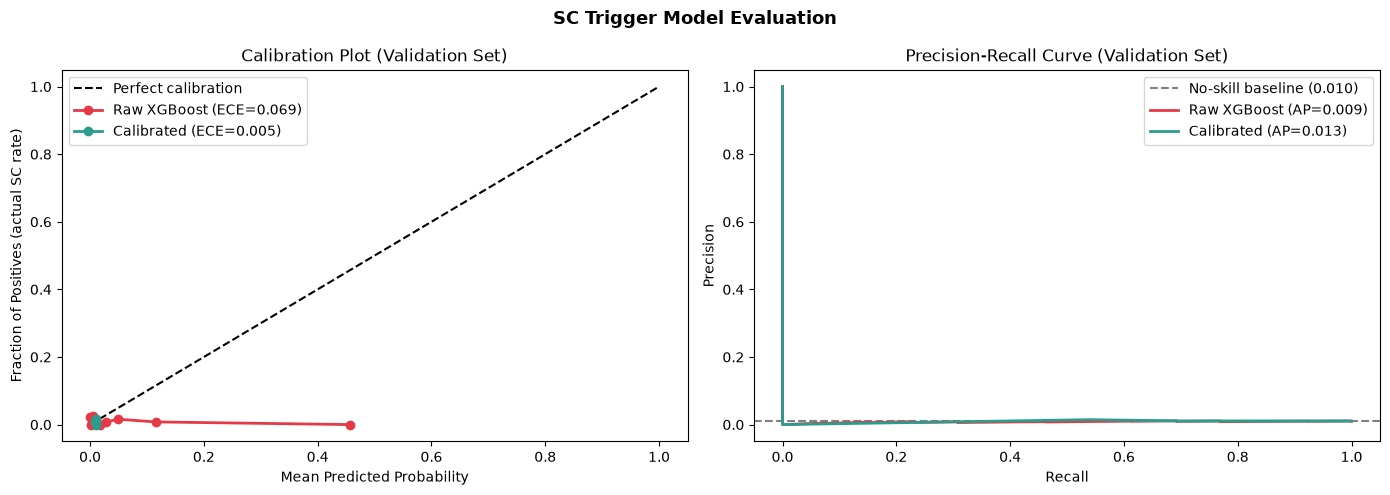

In [12]:
# Calibration plot
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Reliability diagram
ax1.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Perfect calibration')
for probs, label, color in [
    (raw_val_probs, 'Raw XGBoost',   '#E63946'),
    (cal_val_probs, 'Calibrated',     '#2A9D8F'),
]:
    pt, pp = calibration_curve(y_val.values, probs, n_bins=10, strategy='quantile')
    ece = float(np.mean(np.abs(pt - pp)))
    ax1.plot(pp, pt, 'o-', color=color, label=f'{label} (ECE={ece:.3f})', linewidth=2)

ax1.set_xlabel('Mean Predicted Probability')
ax1.set_ylabel('Fraction of Positives (actual SC rate)')
ax1.set_title('Calibration Plot (Validation Set)')
ax1.legend()

# Precision-Recall curve
ax2.axhline(float(y_val.mean()), color='gray', linestyle='--',
            label=f'No-skill baseline ({y_val.mean():.3f})')
for probs, label, color in [
    (raw_val_probs, 'Raw XGBoost',   '#E63946'),
    (cal_val_probs, 'Calibrated',     '#2A9D8F'),
]:
    prec, rec, _ = precision_recall_curve(y_val.values, probs)
    ap = average_precision_score(y_val.values, probs)
    ax2.plot(rec, prec, color=color, label=f'{label} (AP={ap:.3f})', linewidth=2)

ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve (Validation Set)')
ax2.legend()

plt.suptitle('SC Trigger Model Evaluation', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


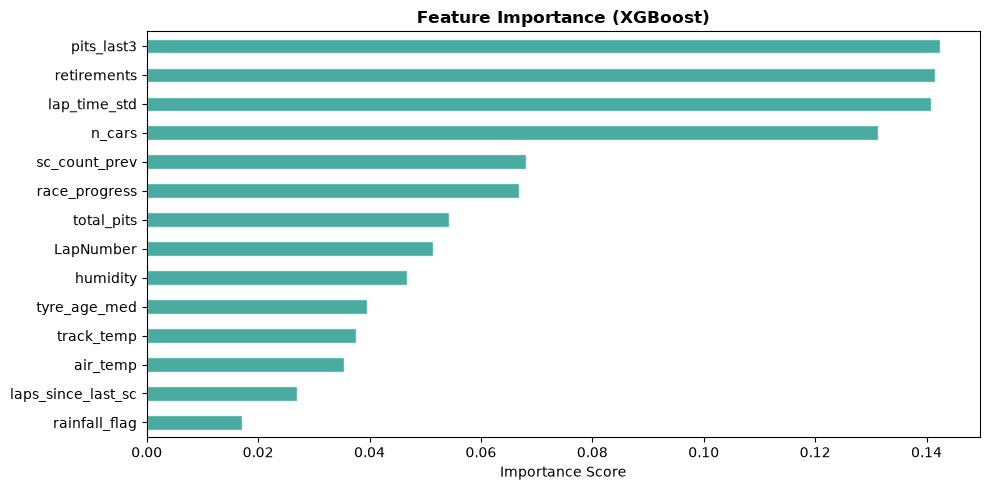

In [13]:
# Feature importance
feat_imp = pd.Series(
    model.feature_importances_,
    index=avail_features
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 5))
feat_imp.plot(kind='barh', ax=ax, color='#2A9D8F', alpha=0.85, edgecolor='white')
ax.set_title('Feature Importance (XGBoost)', fontsize=12, fontweight='bold')
ax.set_xlabel('Importance Score')
plt.tight_layout()
plt.show()


---

## 12. Final Test Set Evaluation

Run **once** on the held-out test set (2024 season).


In [14]:
raw_test_probs = model.predict_proba(X_test)[:, 1]
cal_test_probs = calibrator.predict(raw_test_probs)

print('=== Test Set Evaluation (2024 -- unseen) ===')
evaluate(y_test.values, raw_test_probs, 'XGBoost (raw)')
evaluate(y_test.values, cal_test_probs, 'XGBoost (calibrated)')


=== Test Set Evaluation (2024 -- unseen) ===
[XGBoost (raw)]
  Brier Score : 0.0226  (lower = better, baseline = 0.0065)
  PR-AUC      : 0.0634  (higher = better, baseline = 0.0065)
  ROC-AUC     : 0.5523

[XGBoost (calibrated)]
  Brier Score : 0.0065  (lower = better, baseline = 0.0065)
  PR-AUC      : 0.0074  (higher = better, baseline = 0.0065)
  ROC-AUC     : 0.5590



{'label': 'XGBoost (calibrated)',
 'brier': 0.006496024318039417,
 'pr_auc': 0.007436166972140921,
 'roc_auc': 0.5589618815896188}

---

## 13. Save Model

Saves both the XGBoost model and the calibrator to `models/`. The simulation engine loads these at startup — no retraining during a live race.


In [15]:
model_path      = os.path.join(MODEL_DIR, 'sc_trigger_xgboost.joblib')
calibrator_path = os.path.join(MODEL_DIR, 'sc_trigger_calibrator.joblib')
features_path   = os.path.join(MODEL_DIR, 'sc_trigger_features.joblib')

joblib.dump(model,           model_path)
joblib.dump(calibrator,      calibrator_path)
joblib.dump(avail_features,  features_path)

print(f'Model saved      : {model_path}')
print(f'Calibrator saved : {calibrator_path}')
print(f'Feature list     : {features_path}')
print()
print('To use in the simulation engine:')
print("  model      = joblib.load('models/SC Estimation/sc_trigger_xgboost.joblib')")
print("  calibrator = joblib.load('models/SC Estimation/sc_trigger_calibrator.joblib')")
print("  features   = joblib.load('models/SC Estimation/sc_trigger_features.joblib')")
print("  raw_prob   = model.predict_proba(X)[0, 1]")
print("  sc_prob    = calibrator.predict([raw_prob])[0]")


Model saved      : models\sc_trigger_xgboost.joblib
Calibrator saved : models\sc_trigger_calibrator.joblib
Feature list     : models\sc_trigger_features.joblib

To use in the simulation engine:
  model      = joblib.load('models/sc_trigger_xgboost.joblib')
  calibrator = joblib.load('models/sc_trigger_calibrator.joblib')
  features   = joblib.load('models/sc_trigger_features.joblib')
  raw_prob   = model.predict_proba(X)[0, 1]
  sc_prob    = calibrator.predict([raw_prob])[0]


---

## 14. Quick Inference Demo

How the simulation engine will call this model:


In [16]:
def predict_sc_probability(race_state: dict) -> float:
    # Minimal inference function for the simulation engine
    # race_state is a dict with the feature values for one lap
    X = pd.DataFrame([race_state])[avail_features].fillna(0)
    raw  = model.predict_proba(X)[0, 1]
    prob = float(calibrator.predict([raw])[0])
    return round(prob, 4)


# Example: lap 30 of 58, normal conditions, first lap of race with VSC ending
example_state = {
    'LapNumber':          30,
    'race_progress':      30/58,
    'tyre_age_med':       15,
    'lap_time_std':       1.8,
    'retirements':        1,
    'total_pits':         3,
    'pits_last3':         5,
    'track_temp':         38.0,
    'air_temp':           27.0,
    'humidity':           55.0,
    'rainfall_flag':      0,
    'sc_count_prev':      0,
    'laps_since_last_sc': 999,
    'n_cars':             19,
}

sc_prob = predict_sc_probability(example_state)
print(f'P(SC deploys this lap) = {sc_prob:.1%}')
print()
# Higher risk: wet race, recent retirement, elevated tyre age
high_risk_state = {**example_state,
    'rainfall_flag': 1,
    'retirements':   3,
    'tyre_age_med':  28,
    'lap_time_std':  4.2,
}
sc_prob_high = predict_sc_probability(high_risk_state)
print(f'P(SC deploys this lap) [high risk] = {sc_prob_high:.1%}')


P(SC deploys this lap) = 1.1%

P(SC deploys this lap) [high risk] = 1.1%


---

## Summary

| Step | What was done |
|------|---------------|
| Data | Loaded all FastF1 CSVs, aggregated to race-lap level |
| Label | `sc_deployed = 1` when SC first activates on a lap |
| Features | 14 causal features (no future data) |
| Split | Chronological: 2018-2022 train / 2023 val / 2024 test |
| Imbalance | SMOTE on training set only |
| Model | XGBoost classifier |
| Calibration | Isotonic regression fitted on val set |
| Output | `P(SC deploys this lap)` in [0,1] |
| Saved | `models/sc_trigger_xgboost.joblib` + calibrator + feature list |

**Next model to train (Phase 2 continues):** SC Duration Model — empirical histogram of how many laps each SC period lasts.
